In [1]:
# pip install mlflow opencv-python opencv-contrib-python ultralytics

In [ ]:
# import os
# from ultralytics import YOLO

# # --- DÉFINITION DYNAMIQUE DU CHEMIN (STANDARD DOCKER) ---
# # os.path.abspath(__file__) trouve où est le script actuel.
# # os.path.dirname() prend le dossier qui contient ce script (votre racine Projet_Capstone_IA).
# BASE_DIR = os.path.dirname(os.path.abspath(__file__))

# # --- ÉTAPE 1 : GESTION DES DONNÉES ---
# # On pointe dynamiquement vers votre dossier existant.
# # Plus besoin de la clé d'API Roboflow ni de télécharger à chaque fois !
# chemin_data_yaml = os.path.join(BASE_DIR, "Parking-Control-School-2", "data.yaml")

# if not os.path.exists(chemin_data_yaml):
#     print(f"Erreur critique : Le fichier de configuration n'a pas été trouvé au chemin : {chemin_data_yaml}")
# else:
#     # --- ÉTAPE 2 : CHARGEMENT DU MODÈLE ---
#     # On cherche yolov8n.pt dynamiquement à la racine
#     chemin_modele_initial = os.path.join(BASE_DIR, "yolov8n.pt")
    
#     # Si le fichier de base n'est pas trouvé (ex: dans Docker), YOLO le téléchargera automatiquement
#     if not os.path.exists(chemin_modele_initial):
#         print("Modèle de base introuvable localement. Téléchargement automatique par Ultralytics...")
#         chemin_modele_initial = "yolov8n.pt" 
        
#     model = YOLO(chemin_modele_initial)

#     # --- ÉTAPE 3 : ENTRAÎNEMENT CONTRÔLÉ ---
#     # On fixe le dossier de sortie dynamiquement
#     chemin_sauvegarde = os.path.join(BASE_DIR, "runs", "detect")

#     print(f"Démarrage de l'entraînement. Dossier racine reconnu : {BASE_DIR}")
#     model.train(
#         data=chemin_data_yaml,
#         epochs=50,
#         imgsz=640,
#         plots=True,
#         project=chemin_sauvegarde,
#         name="train",
#         exist_ok=True # Écrase les anciens poids au lieu de générer "train2", "train3", etc.
#     )

In [5]:
# import os
# import sys
# from pathlib import Path
# from ultralytics import YOLO

# # --- CONFIGURATION DES CHEMINS (APPROCHE LOGICIELLE) ---
# # Utilisation de pathlib pour une manipulation de chemins plus robuste (Windows/Linux)
# BASE_DIR = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()

# # Définition des dossiers clés en chemins relatifs
# DATASET_PATH = BASE_DIR / "Parking-Control-School-2" / "data.yaml"
# RUNS_DIR = BASE_DIR / "runs"
# MODEL_WEIGHTS = "yolov8n.pt"

# def verify_environment():
#     """Vérifie la présence des fichiers critiques avant de lancer l'IA."""
#     if not DATASET_PATH.exists():
#         print(f"❌ ERREUR CRITIQUE : Fichier de données introuvable -> {DATASET_PATH}")
#         print("Vérifiez que le dossier 'Parking-Control-School-2' est bien à la racine du projet.")
#         return False
    
#     # Création automatique du dossier 'runs' s'il n'existe pas
#     RUNS_DIR.mkdir(parents=True, exist_ok=True)
#     return True

# def start_training():
#     """Initialise et lance l'entraînement du modèle YOLO."""
#     if not verify_environment():
#         return

#     print(f"🚀 Initialisation de l'entraînement...")
#     print(f"📍 Racine : {BASE_DIR}")
    
#     # Chargement du modèle
#     model = YOLO(MODEL_WEIGHTS)

#     # Lancement de l'entraînement
#     # Note : imgsz=640 est standard, mais vous pouvez le réduire à 320 pour tester la vitesse
#     model.train(
#         data=str(DATASET_PATH),       # YOLO attend une chaîne de caractères
#         epochs=50,
#         imgsz=640,
#         plots=True,
#         project=str(RUNS_DIR),        # Organisation des sorties
#         name="detect_parking",
#         exist_ok=True,
#         device="0" if os.name != 'posix' else 'cpu' # Utilise le GPU si disponible (Windows)
#     )

# if __name__ == "__main__":
#     start_training()

In [1]:
import sys
from pathlib import Path
from ultralytics import YOLO, settings

class ModelTrainer:
    """
    Classe responsable de l'entrainement du modele de detection (VisionService).
    Encapsule la configuration des chemins et de YOLOv8 de maniere robuste.
    """
    def __init__(self):
        # 1. Definition dynamique et securisee des chemins avec pathlib
        try:
            self.base_dir = Path(__file__).resolve().parent
        except NameError:
            self.base_dir = Path.cwd()
            
        print(f"[INFO] Dossier racine detecte : {self.base_dir}")
        
        self.data_yaml_path = self.base_dir / "Parking-Control-School-2" / "data.yaml"
        self.runs_dir = self.base_dir / "runs"
        
        # 2. Desactivation de l'integration MLflow interne
        settings.update({"mlflow": False})
        print("[INFO] Integration MLflow interne de YOLO desactivee pour eviter les conflits de cache.")

    def train_model(self, epochs: int = 50, imgsz: int = 640):
        """
        Lance l'entrainement du modele YOLO avec des parametres optimises.
        """
        if not self.data_yaml_path.exists():
            print(f"[ERREUR] Le fichier de donnees est introuvable a : {self.data_yaml_path}")
            sys.exit(1)

        print("[INFO] Chargement de l'architecture YOLOv8n...")
        model = YOLO("yolov8n.pt")

        print(f"[INFO] Lancement de l'entrainement pour {epochs} epochs...")
        
        # 3. Lancement avec optimisations Windows / Jupyter
        model.train(
            data=str(self.data_yaml_path),
            epochs=epochs,
            imgsz=imgsz,
            plots=False,  
            batch=8,      
            workers=0,    # CRITIQUE : Force l'affichage de la barre de progression sous Windows/Jupyter
            project=str(self.runs_dir),
            name="detect_parking",
            exist_ok=True
        )
        
        print("[SUCCES] Entrainement termine. Les poids sont sauvegardes dans le dossier 'runs'.")

# --- BLOC D'EXECUTION ---
if __name__ == "__main__":
    trainer = ModelTrainer()
    trainer.train_model(epochs=50)

[INFO] Dossier racine detecte : c:\Users\user\Desktop\001 INTELLIGENCE ARTIFICIELLE EN INFORMATIQUE\Session 4 Semestre 4 IA 2\Projet Capstone en IA\Projet_Capstone_IA
[INFO] Integration MLflow interne de YOLO desactivee pour eviter les conflits de cache.
[INFO] Chargement de l'architecture YOLOv8n...
[INFO] Lancement de l'entrainement pour 50 epochs...
New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.40  Python-3.11.9 torch-2.10.0+cu130 CUDA:0 (Quadro T1000, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\user\Desktop\001 INTELLIGENCE ARTIFICIELLE EN INFORMATIQUE\Session 4 Semestre 4 IA 2\Projet Capstone en IA\Projet_Capstone_IA\Parking-Control-School-2\data.y

[INFO] Initialisation du VisionService...
[INFO] Modele YOLO charge avec succes et pret pour l'inference.
[INFO] Analyse visuelle en cours pour : 206.jpg


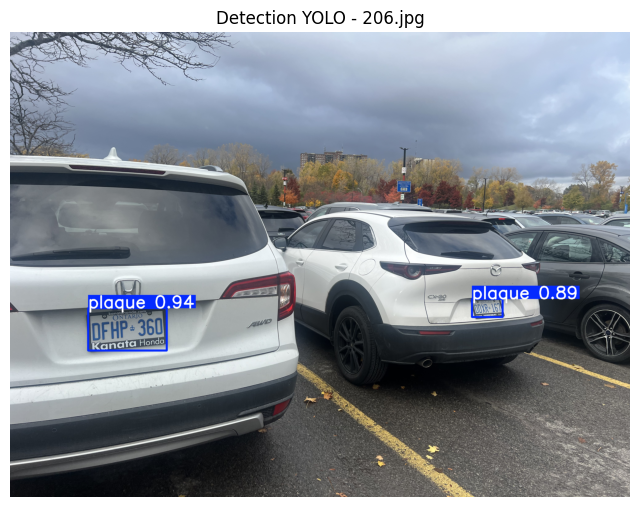

In [2]:
import sys
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

class VisionService:
    """
    Service responsable de la detection visuelle des vehicules et plaques.
    Encapsule le modele YOLOv8 pour optimiser la gestion de la memoire (Singleton pattern local).
    """
    def __init__(self, model_filename: str = "best.pt"):
        # 1. Definition dynamique des chemins avec pathlib
        try:
            self.base_dir = Path(__file__).resolve().parent
        except NameError:
            self.base_dir = Path.cwd()

        self.images_dir = self.base_dir / "images"
        model_path = self.base_dir / model_filename

        # 2. Chargement du modele (Execute UNE SEULE FOIS a l'instanciation)
        print("[INFO] Initialisation du VisionService...")
        if not model_path.exists():
            print(f"[ALERTE] Modele '{model_filename}' introuvable. Utilisation du modele de base 'yolov8n.pt'.")
            self.model_path = "yolov8n.pt"
        else:
            self.model_path = str(model_path)

        # Chargement en memoire vive
        self.model = YOLO(self.model_path)
        print("[INFO] Modele YOLO charge avec succes et pret pour l'inference.")

    def predict(self, image_path: Path, conf: float = 0.5):
        """
        Methode coeur : Effectue l'inference pure sur une image donnee.
        Ne contient AUCUNE logique d'affichage, retourne uniquement les donnees brutes.
        """
        if not image_path.exists():
            raise FileNotFoundError(f"L'image est introuvable au chemin : {image_path}")
        
        # verbose=False pour garder le terminal propre en production
        return self.model.predict(source=str(image_path), conf=conf, verbose=False)

    def tester_et_afficher(self, nom_image: str, conf: float = 0.5):
        """
        Methode utilitaire pour le developpement : utilise predict() puis affiche le resultat.
        """
        chemin_image = self.images_dir / nom_image
        
        try:
            print(f"[INFO] Analyse visuelle en cours pour : {nom_image}")
            # Appel a la methode d'inference decouplee
            results = self.predict(chemin_image, conf=conf)

            # Affichage (Standardisation des couleurs pour Matplotlib)
            for r in results:
                img_rgb = cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB) 
                plt.figure(figsize=(8, 8))
                plt.imshow(img_rgb)
                plt.title(f"Detection YOLO - {nom_image}")
                plt.axis('off')
                plt.show()

        except FileNotFoundError as e:
            print(f"[ERREUR] {e}")
        except Exception as e:
            print(f"[ERREUR] Echec inattendu lors de la detection : {e}")

# --- BLOC D'EXECUTION PRINCIPAL ---
if __name__ == "__main__":
    # 1. On "allume" le service (le modele monte en RAM a ce moment-la)
    vision_service = VisionService(model_filename="best.pt")
    
    # 2. On peut maintenant soumettre autant d'images que l'on veut tres rapidement
    vision_service.tester_et_afficher("206.jpg", conf=0.5)
    
    # Exemple : vision_service.tester_et_afficher("IMG_4201.jpg") s'executerait instantanement

[INFO] Test du module de vision sur le sous-dossier 'new'...
[INFO] Analyse visuelle en cours pour : new\IMG_4213.jpg


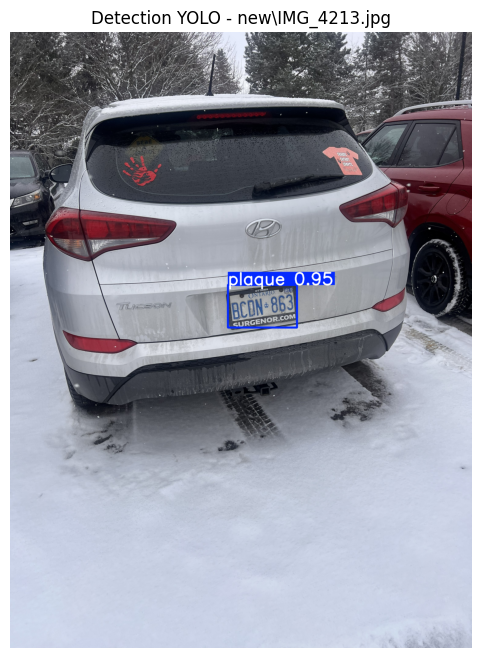

In [3]:
import sys
from pathlib import Path

# NOTE : Si vous etiez dans le fichier final (app.py ou main.py), 
# vous feriez simplement : from services.vision_service import VisionService

# --- BLOC D'EXECUTION (TEST DU SOUS-DOSSIER 'new') ---
if __name__ == "__main__":
    print("[INFO] Test du module de vision sur le sous-dossier 'new'...")
    
    # 1. Verification si le service est deja en memoire (Singleton local)
    # Dans un vrai serveur, cela est fait une seule fois au demarrage
    try:
        if 'vision_service' not in globals():
            vision_service = VisionService(model_filename="best.pt")
    except NameError:
        print("[ERREUR] La classe VisionService n'est pas definie. Executez la cellule precedente d'abord.")
        sys.exit(1)

    # 2. Utilisation de pathlib pour gerer le sous-dossier de maniere universelle
    # Path("new") / "IMG_4213.jpg" donnera "new/IMG_4213.jpg" sur Linux/Docker et "new\IMG_4213.jpg" sur Windows
    chemin_relatif_image = Path("new") / "IMG_4213.jpg"
    
    # 3. Execution de l'inference
    vision_service.tester_et_afficher(nom_image=str(chemin_relatif_image), conf=0.5)

[INFO] Initialisation du Pipeline ALPR complet...
[INFO] Initialisation du OCRService (EasyOCR)...

[INFO] Analyse de l'image en cours : 9.jpg
Numero detecte : QUEBEC (Confiance: 1.00)


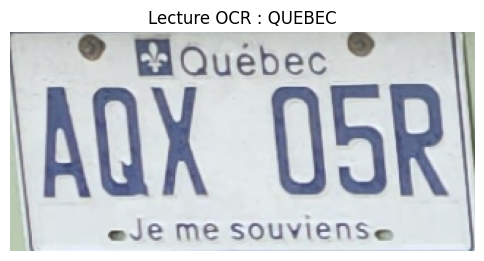

Numero detecte : A_X   O5RL (Confiance: 0.12)


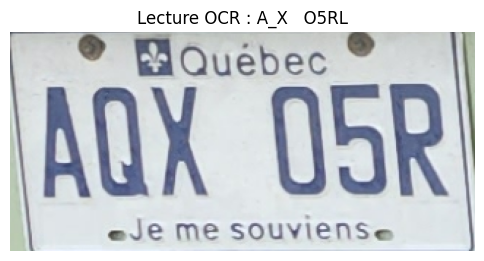

Numero detecte : JE ME SOUVIENS_ (Confiance: 0.88)


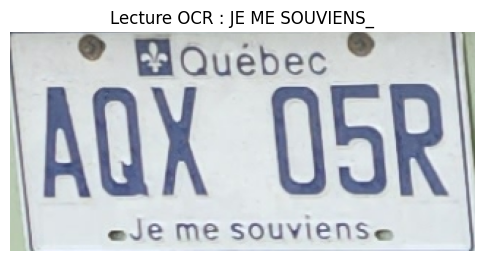

In [4]:
import sys
from pathlib import Path
import cv2
import easyocr
import matplotlib.pyplot as plt
from ultralytics import YOLO

class OCRService:
    """
    Service independant dedie a l'extraction de texte (Reconnaissance Optique de Caracteres).
    Totalement decouple de YOLO, il peut etre teste et ameliore de maniere isolee.
    """
    def __init__(self, langs=['en']):
        print("[INFO] Initialisation du OCRService (EasyOCR)...")
        # Le parametre gpu=True est gere automatiquement par EasyOCR s'il detecte CUDA
        self.reader = easyocr.Reader(langs)

    def extraire_texte(self, image_crop):
        """
        Prend un tableau numpy (image decoupee) et retourne les resultats OCR bruts.
        """
        return self.reader.readtext(image_crop)

class ALPRPipeline:
    """
    Orchestrateur principal. Il combine le modele de vision (YOLO) et le service OCR.
    """
    def __init__(self, model_filename: str = "best.pt"):
        # 1. Gestion dynamique des chemins (Compatible Windows / Linux / Docker)
        try:
            self.base_dir = Path(__file__).resolve().parent
        except NameError:
            self.base_dir = Path.cwd()

        self.images_dir = self.base_dir / "images"
        model_path = self.base_dir / model_filename

        # 2. Initialisation des modeles
        print("[INFO] Initialisation du Pipeline ALPR complet...")
        if not model_path.exists():
            print(f"[ALERTE] Modele {model_filename} introuvable. Utilisation de yolov8n.pt")
            self.model_path = "yolov8n.pt"
        else:
            self.model_path = str(model_path)

        # Chargement en RAM
        self.model = YOLO(self.model_path)
        self.ocr_service = OCRService()

    def analyser_image(self, nom_image: str):
        """
        Logique metier pure : Detection -> Decoupage -> OCR.
        Ne contient AUCUN code d'affichage (pret pour API).
        Retourne une liste de dictionnaires contenant les resultats.
        """
        chemin_image = self.images_dir / nom_image

        if not chemin_image.exists():
            print(f"[ERREUR] L'image {nom_image} est introuvable au chemin : {chemin_image}")
            return []

        img = cv2.imread(str(chemin_image))
        if img is None:
            print(f"[ERREUR] Impossible de decoder l'image : {chemin_image}")
            return []

        # Inferences YOLO
        results = self.model.predict(source=img, conf=0.5, verbose=False)
        resultats_finaux = []

        for r in results:
            for box in r.boxes:
                # Recuperation et securisation des coordonnees (Out of Bounds prevention)
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                y1, y2 = max(0, y1), min(img.shape[0], y2)
                x1, x2 = max(0, x1), min(img.shape[1], x2)

                plaque_crop = img[y1:y2, x1:x2]
                
                # Ignorer les decoupages vides
                if plaque_crop.size == 0:
                    continue

                # Delegation de la lecture au service OCR
                lectures_ocr = self.ocr_service.extraire_texte(plaque_crop)
                
                for (bbox, text, prob) in lectures_ocr:
                    # Stockage structure des donnees
                    resultats_finaux.append({
                        "texte": text.upper(),
                        "confiance": prob,
                        "crop": plaque_crop
                    })

        return resultats_finaux

    def tester_et_afficher(self, nom_image: str):
        """
        Fonction utilitaire pour les developpeurs.
        Appelle la logique metier puis affiche les donnees via Matplotlib.
        """
        print(f"\n[INFO] Analyse de l'image en cours : {nom_image}")
        resultats = self.analyser_image(nom_image)

        if not resultats:
            print("[ALERTE] Aucune plaque valide n'a ete lue sur cette image.")
            return

        for res in resultats:
            print(f"Numero detecte : {res['texte']} (Confiance: {res['confiance']:.2f})")
            
            # Affichage graphique separe de la logique
            plt.figure(figsize=(6, 3))
            plt.imshow(cv2.cvtColor(res['crop'], cv2.COLOR_BGR2RGB))
            plt.title(f"Lecture OCR : {res['texte']}")
            plt.axis('off')
            plt.show()

# --- BLOC D'EXECUTION PRINCIPAL ---
if __name__ == "__main__":
    # Instanciation unique des modeles lourds
    pipeline = ALPRPipeline(model_filename="best.pt")
    
    # Execution du test
    pipeline.tester_et_afficher("9.jpg")

[INFO] Initialisation du Pipeline ALPR complet...
[INFO] Initialisation du OCRService (EasyOCR)...

[INFO] Analyse de l'image en cours : 7.jpg
NUMERO DETECTE : CA40465 (Confiance: 0.65)


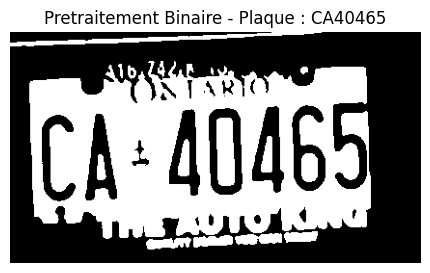

In [9]:
import sys
from pathlib import Path
import cv2
import easyocr
import matplotlib.pyplot as plt
from ultralytics import YOLO

# --- 1. CONFIGURATION CENTRALISEE ---
class ALPRConfig:
    MOTS_IGNORER = {"ONTARIO", "QUEBEC", "YOURSTODISCOVER", "JEMESOUVIENS", "CANADA"}
    CONF_MIN_YOLO = 0.5
    CONF_MIN_OCR = 0.3        # Ajuste a 30% pour capter les plaques difficiles apres traitement
    LONGUEUR_MIN_PLAQUE = 4
    MARGE_CROP_PIXELS = 5     # Marge pour eviter de couper les bords des lettres

# --- 2. SERVICES INDEPENDANTS ---
class OCRService:
    """
    Service expert en extraction de texte, integrant son propre pipeline de pretraitement d'image.
    """
    def __init__(self, langs=['en']):
        print("[INFO] Initialisation du OCRService (EasyOCR)...")
        self.reader = easyocr.Reader(langs)

    def pretraiter_image(self, img_crop):
        """
        Le 'Pretraitement Magique' : ameliore drastiquement la nettete pour EasyOCR.
        """
        gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
        # Agrandissement (x2)
        gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
        # Reduction du bruit avec preservation des contours
        gray = cv2.bilateralFilter(gray, 11, 17, 17)
        # Binarisation noire et blanche
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return thresh

    def nettoyer_texte(self, texte_brut: str) -> str:
        return texte_brut.upper().replace(" ", "").replace("-", "").replace(".", "")

    def valider_plaque(self, texte_nettoye: str, confiance: float) -> bool:
        """Application stricte des regles d'affaires de La Cite."""
        if confiance < ALPRConfig.CONF_MIN_OCR:
            return False
        if len(texte_nettoye) < ALPRConfig.LONGUEUR_MIN_PLAQUE:
            return False
        if texte_nettoye in ALPRConfig.MOTS_IGNORER:
            return False
        if not any(char.isdigit() for char in texte_nettoye): # Doit contenir un chiffre
            return False
        return True

    def extraire_meilleure_plaque(self, image_crop) -> dict:
        # 1. On prepare l'image avant de l'envoyer a l'IA
        image_prete = self.pretraiter_image(image_crop)
        
        # 2. Lecture sur l'image amelioree
        resultats = self.reader.readtext(image_prete)
        
        meilleur_candidat = {
            "texte": None, 
            "confiance": 0.0, 
            "image_binaire": image_prete # Sauvegarde pour le diagnostic visuel
        }

        for (bbox, text, prob) in resultats:
            text_clean = self.nettoyer_texte(text)
            
            if self.valider_plaque(text_clean, prob):
                if prob > meilleur_candidat["confiance"]:
                    meilleur_candidat["texte"] = text_clean
                    meilleur_candidat["confiance"] = prob
                    
        return meilleur_candidat

class ALPRPipeline:
    """
    Orchestrateur combinant YOLOv8 et le Service OCR.
    """
    def __init__(self, model_filename: str = "best.pt"):
        try:
            self.base_dir = Path(__file__).resolve().parent
        except NameError:
            self.base_dir = Path.cwd()

        self.images_dir = self.base_dir / "images"
        model_path = self.base_dir / model_filename

        print("[INFO] Initialisation du Pipeline ALPR complet...")
        if not model_path.exists():
            print(f"[ALERTE] Modele {model_filename} introuvable. Utilisation de yolov8n.pt")
            self.model_path = "yolov8n.pt"
        else:
            self.model_path = str(model_path)

        self.model = YOLO(self.model_path)
        self.ocr_service = OCRService()

    def analyser_image(self, nom_image: str):
        chemin_image = self.images_dir / nom_image

        if not chemin_image.exists():
            print(f"[ERREUR] L'image {nom_image} est introuvable au chemin : {chemin_image}")
            return []

        img = cv2.imread(str(chemin_image))
        if img is None:
            print(f"[ERREUR] Impossible de decoder l'image : {chemin_image}")
            return []

        results = self.model.predict(source=img, conf=ALPRConfig.CONF_MIN_YOLO, verbose=False)
        resultats_finaux = []

        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                
                # Application securisee de la marge de decoupage
                marge = ALPRConfig.MARGE_CROP_PIXELS
                y1, y2 = max(0, y1 - marge), min(img.shape[0], y2 + marge)
                x1, x2 = max(0, x1 - marge), min(img.shape[1], x2 + marge)

                plaque_crop = img[y1:y2, x1:x2]
                
                if plaque_crop.size == 0:
                    continue

                resultat_ocr = self.ocr_service.extraire_meilleure_plaque(plaque_crop)
                
                if resultat_ocr["texte"]:
                    resultats_finaux.append({
                        "texte": resultat_ocr["texte"],
                        "confiance": resultat_ocr["confiance"],
                        "crop_original": plaque_crop,
                        "crop_filtre": resultat_ocr["image_binaire"]
                    })

        return resultats_finaux

    def tester_et_afficher(self, nom_image: str):
        print(f"\n[INFO] Analyse de l'image en cours : {nom_image}")
        resultats = self.analyser_image(nom_image)

        if not resultats:
            print("[INFO] Aucune plaque valide (ou filtrage metier ecarte les resultats).")
            return

        for res in resultats:
            print(f"NUMERO DETECTE : {res['texte']} (Confiance: {res['confiance']:.2f})")
            
            # Affichage de l'image apres le filtre d'Otsu pour voir exactement ce que l'OCR a lu
            plt.figure(figsize=(6, 3))
            plt.imshow(res['crop_filtre'], cmap='gray')
            plt.title(f"Pretraitement Binaire - Plaque : {res['texte']}")
            plt.axis('off')
            plt.show()

# --- BLOC D'EXECUTION PRINCIPAL ---
if __name__ == "__main__":
    pipeline = ALPRPipeline(model_filename="best.pt")
    pipeline.tester_et_afficher("7.jpg")

[INFO] Initialisation du Pipeline ALPR complet...
[INFO] Initialisation du OCRService (EasyOCR)...

[INFO] Analyse de l'image en cours : 7.jpg
NUMERO DETECTE : CA40465 (Score: 0.65)


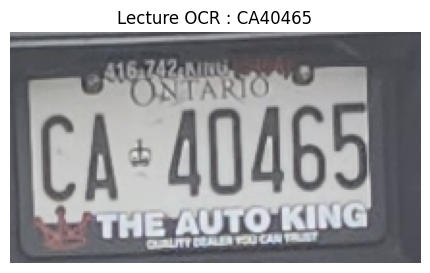

In [10]:
import sys
from pathlib import Path
import cv2
import easyocr
import matplotlib.pyplot as plt
from ultralytics import YOLO

# --- 1. CONFIGURATION CENTRALISEE ---
class ALPRConfig:
    """
    Parametres metier et constantes du systeme.
    """
    MOTS_IGNORER = {"ONTARIO", "QUEBEC", "YOURSTODISCOVER", "JEMESOUVIENS", "CANADA", "ONT", "QC"}
    CONF_MIN_YOLO = 0.5
    CONF_MIN_OCR = 0.3
    LONGUEUR_MIN_PLAQUE = 4
    MARGE_CROP_PIXELS = 5  # Votre marge de securite integree a la configuration

# --- 2. SERVICES INDEPENDANTS ---
class OCRService:
    """
    Service expert en extraction de texte, incluant le pretraitement de l'image.
    """
    def __init__(self, langs=['en']):
        print("[INFO] Initialisation du OCRService (EasyOCR)...")
        self.reader = easyocr.Reader(langs)

    def pretraiter_image(self, img_crop):
        """
        Ameliore le contraste et la nettete pour faciliter le travail d'EasyOCR.
        """
        gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
        gray = cv2.bilateralFilter(gray, 11, 17, 17)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return thresh

    def nettoyer_texte(self, texte_brut: str) -> str:
        """Nettoie la chaine de caracteres lue par l'OCR."""
        return texte_brut.upper().replace(" ", "").replace("-", "").replace(".", "")

    def valider_plaque(self, texte_nettoye: str, confiance: float) -> bool:
        """Application des regles d'affaires."""
        if confiance < ALPRConfig.CONF_MIN_OCR:
            return False
        if len(texte_nettoye) < ALPRConfig.LONGUEUR_MIN_PLAQUE:
            return False
        if texte_nettoye in ALPRConfig.MOTS_IGNORER:
            return False
        # Doit au moins contenir un chiffre (regle de base d'une plaque d'immatriculation)
        if not any(char.isdigit() for char in texte_nettoye):
            return False
        return True

    def extraire_meilleure_plaque(self, image_crop) -> dict:
        """
        Gere le pipeline OCR complet pour une decoupe d'image.
        """
        image_prete = self.pretraiter_image(image_crop)
        resultats = self.reader.readtext(image_prete)
        
        meilleur_candidat = {
            "texte": None, 
            "confiance": 0.0, 
            "image_binaire": image_prete 
        }

        for (bbox, text, prob) in resultats:
            text_clean = self.nettoyer_texte(text)
            
            if self.valider_plaque(text_clean, prob):
                if prob > meilleur_candidat["confiance"]:
                    meilleur_candidat["texte"] = text_clean
                    meilleur_candidat["confiance"] = prob
                    
        return meilleur_candidat

# --- 3. ORCHESTRATEUR ---
class ALPRPipeline:
    """
    Orchestrateur combinant YOLOv8 et le Service OCR.
    """
    def __init__(self, model_filename: str = "best.pt"):
        try:
            self.base_dir = Path(__file__).resolve().parent
        except NameError:
            self.base_dir = Path.cwd()

        self.images_dir = self.base_dir / "images"
        model_path = self.base_dir / model_filename

        print("[INFO] Initialisation du Pipeline ALPR complet...")
        if not model_path.exists():
            print(f"[ALERTE] Modele {model_filename} introuvable. Utilisation de yolov8n.pt")
            self.model_path = "yolov8n.pt"
        else:
            self.model_path = str(model_path)

        self.model = YOLO(self.model_path)
        self.ocr_service = OCRService()

    def analyser_image(self, nom_image: str):
        """
        Execute l'inference et le decoupage avec la marge de securite.
        """
        chemin_image = self.images_dir / nom_image

        if not chemin_image.exists():
            print(f"[ERREUR] L'image {nom_image} est introuvable au chemin : {chemin_image}")
            return []

        img = cv2.imread(str(chemin_image))
        if img is None:
            print(f"[ERREUR] Impossible de decoder l'image : {chemin_image}")
            return []

        hauteur_img, largeur_img = img.shape[:2]
        results = self.model.predict(source=img, conf=ALPRConfig.CONF_MIN_YOLO, verbose=False)
        resultats_finaux = []

        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                
                # Ajout de la marge de pixels avec protection (Prevention Out of Bounds)
                marge = ALPRConfig.MARGE_CROP_PIXELS
                y1_crop = max(0, y1 - marge)
                y2_crop = min(hauteur_img, y2 + marge)
                x1_crop = max(0, x1 - marge)
                x2_crop = min(largeur_img, x2 + marge)

                plaque_crop = img[y1_crop:y2_crop, x1_crop:x2_crop]
                
                if plaque_crop.size == 0:
                    continue

                resultat_ocr = self.ocr_service.extraire_meilleure_plaque(plaque_crop)
                
                if resultat_ocr["texte"]:
                    resultats_finaux.append({
                        "texte": resultat_ocr["texte"],
                        "confiance": resultat_ocr["confiance"],
                        "crop_original": plaque_crop
                    })

        return resultats_finaux

    def tester_et_afficher(self, nom_image: str):
        """
        Affiche les resultats sur le notebook.
        """
        print(f"\n[INFO] Analyse de l'image en cours : {nom_image}")
        resultats = self.analyser_image(nom_image)

        if not resultats:
            print("[INFO] Aucune plaque valide detectee ou le texte a ete filtre.")
            return

        for res in resultats:
            print(f"NUMERO DETECTE : {res['texte']} (Score: {res['confiance']:.2f})")
            
            plt.figure(figsize=(6, 3))
            plt.imshow(cv2.cvtColor(res['crop_original'], cv2.COLOR_BGR2RGB))
            plt.title(f"Lecture OCR : {res['texte']}")
            plt.axis('off')
            plt.show()

# --- BLOC D'EXECUTION PRINCIPAL ---
if __name__ == "__main__":
    pipeline = ALPRPipeline(model_filename="best.pt")
    # Test avec votre image
    pipeline.tester_et_afficher("7.jpg")

In [11]:
import sys
from pathlib import Path
import cv2
import easyocr

class OCRDiagnosticService:
    """
    Version allegee du OCRService dediee aux diagnostics bruts.
    Instancie le modele une seule fois en memoire.
    """
    def __init__(self, langs=['en'], use_gpu=True):
        print("[INFO] Initialisation du Service de Diagnostic OCR...")
        self.reader = easyocr.Reader(langs, gpu=use_gpu)

    def evaluer_bruit_visuel(self, chemin_image: Path):
        """
        Analyse une image complete sans utiliser YOLO.
        Utile pour identifier les faux positifs (textes parasites).
        """
        if not chemin_image.exists():
            print(f"[ERREUR] Image introuvable au chemin : {chemin_image}")
            return

        print(f"[INFO] Chargement de l'image de test : {chemin_image.name}")
        img = cv2.imread(str(chemin_image))
        
        if img is None:
            print("[ERREUR] Impossible de decoder le fichier (potentiellement corrompu).")
            return

        print("[INFO] Analyse de l'image entiere en cours...")
        # Lecture brute, sans notre filtre d'Otsu ni nos regles metier
        resultats = self.reader.readtext(img)

        print("\n--- TOUS LES TEXTES DETECTES (EVALUATION DU BRUIT) ---")
        if not resultats:
            print("Aucun texte detecte sur cette image.")
        else:
            for (bbox, texte, conf) in resultats:
                print(f" -> '{texte}' (Confiance: {conf:.2f})")
        print("------------------------------------------------------")

# --- BLOC D'EXECUTION PRINCIPAL ---
if __name__ == "__main__":
    # 1. Gestion securisee des chemins
    try:
        base_dir = Path(__file__).resolve().parent
    except NameError:
        base_dir = Path.cwd()

    images_dir = base_dir / "images"
    
    # 2. Instanciation du service (le modele monte en RAM ici)
    diagnostic = OCRDiagnosticService()
    
    # 3. Test sur votre image (verifiez bien l'extension dans votre dossier)
    image_test = images_dir / "89.jpg" 
    
    diagnostic.evaluer_bruit_visuel(image_test)

[INFO] Initialisation du Service de Diagnostic OCR...
[INFO] Chargement de l'image de test : 89.jpg
[INFO] Analyse de l'image entiere en cours...

--- TOUS LES TEXTES DETECTES (EVALUATION DU BRUIT) ---
 -> 'URRAR78S]' (Confiance: 0.09)
 -> 'IFNM# 062]' (Confiance: 0.41)
 -> 'YCUItS 'TVO' (Confiance: 0.12)
 -> 'DXCCa' (Confiance: 0.04)
------------------------------------------------------


[INFO] Initialisation du Pipeline ALPR complet...
[INFO] Initialisation du OCRService (EasyOCR)...

[INFO] Analyse de l'image en cours : IMG_4201.jpg
PLAQUE EXTRAITE : LLE3KPB (Confiance : 0.08)


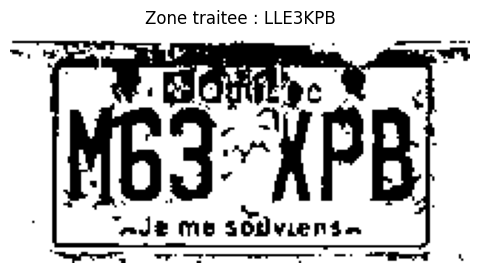

In [12]:
import sys
import re
from pathlib import Path
import cv2
import easyocr
import matplotlib.pyplot as plt
from ultralytics import YOLO

# --- 1. CONFIGURATION CENTRALISEE ---
class ALPRConfig:
    MOTS_IGNORER = {"QUEBEC", "ONTARIO", "CANADA", "JEMESOUVIENS", "YOURSTODISCOVER"}
    CONF_MIN_YOLO = 0.5
    MARGE_DYNAMIQUE_POURCENT = 0.10  # 10% de marge adaptee a la taille de la boite

# --- 2. SERVICES INDEPENDANTS ---
class OCRService:
    """
    Expert en texte : integre la Regex et le filtre d'Otsu.
    """
    def __init__(self, langs=['en']):
        print("[INFO] Initialisation du OCRService (EasyOCR)...")
        self.reader = easyocr.Reader(langs)

    def pretraiter_image(self, img_crop):
        """Pretraitement binaire avec la methode d'Otsu."""
        gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return thresh

    def nettoyer_texte(self, texte_brut: str) -> str:
        """Nettoyage strict par Expression Reguliere (A-Z et 0-9)."""
        return re.sub(r'[^A-Z0-9]', '', texte_brut.upper())

    def valider_plaque(self, texte_nettoye: str) -> bool:
        """Verifie la validite metier de la chaine."""
        if len(texte_nettoye) < 4:
            return False
        if texte_nettoye in ALPRConfig.MOTS_IGNORER:
            return False
        if not any(char.isdigit() for char in texte_nettoye):
            return False
        return True

    def extraire_candidats(self, image_crop) -> list:
        """
        Traite l'image et retourne une liste triee des meilleurs textes trouves.
        """
        image_prete = self.pretraiter_image(image_crop)
        resultats_ocr = self.reader.readtext(image_prete)
        
        candidats = []
        for (bbox, text, prob) in resultats_ocr:
            t_clean = self.nettoyer_texte(text)
            
            if self.valider_plaque(t_clean):
                candidats.append({
                    "texte": t_clean, 
                    "confiance": prob, 
                    "image_binaire": image_prete
                })
        
        # Tri de la liste par indice de confiance decroissant (le plus eleve en premier)
        candidats.sort(key=lambda x: x["confiance"], reverse=True)
        return candidats

# --- 3. ORCHESTRATEUR ---
class ALPRPipeline:
    """
    Orchestrateur combinant Vision et OCR avec calcul des marges dynamiques.
    """
    def __init__(self, model_filename: str = "best.pt"):
        try:
            self.base_dir = Path(__file__).resolve().parent
        except NameError:
            self.base_dir = Path.cwd()

        # Ciblage specifique du sous-dossier 'new' selon votre demande
        self.images_dir = self.base_dir / "images" / "new" 
        model_path = self.base_dir / model_filename

        print("[INFO] Initialisation du Pipeline ALPR complet...")
        if not model_path.exists():
            print(f"[ALERTE] Modele {model_filename} introuvable. Utilisation de yolov8n.pt")
            self.model_path = "yolov8n.pt"
        else:
            self.model_path = str(model_path)

        self.model = YOLO(self.model_path)
        self.ocr_service = OCRService()

    def analyser_image(self, nom_image: str):
        chemin_image = self.images_dir / nom_image

        if not chemin_image.exists():
            print(f"[ERREUR] L'image {nom_image} est introuvable au chemin : {chemin_image}")
            return []

        img = cv2.imread(str(chemin_image))
        if img is None:
            print(f"[ERREUR] Impossible de decoder l'image : {chemin_image}")
            return []

        results = self.model.predict(source=img, conf=ALPRConfig.CONF_MIN_YOLO, verbose=False)
        resultats_finaux = []

        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                
                # --- CALCUL DE LA MARGE DYNAMIQUE ---
                h, w = y2 - y1, x2 - x1
                offset_h = int(h * ALPRConfig.MARGE_DYNAMIQUE_POURCENT)
                offset_w = int(w * ALPRConfig.MARGE_DYNAMIQUE_POURCENT)
                
                y1_crop = max(0, y1 - offset_h)
                y2_crop = min(img.shape[0], y2 + offset_h)
                x1_crop = max(0, x1 - offset_w)
                x2_crop = min(img.shape[1], x2 + offset_w)

                plaque_crop = img[y1_crop:y2_crop, x1_crop:x2_crop]
                
                if plaque_crop.size == 0:
                    continue

                # Delegation de l'extraction et du tri
                candidats = self.ocr_service.extraire_candidats(plaque_crop)
                
                if candidats:
                    # On ne garde que le gagnant (index 0) apres le tri
                    meilleur_candidat = candidats[0] 
                    resultats_finaux.append(meilleur_candidat)

        return resultats_finaux

    def tester_et_afficher(self, nom_image: str):
        print(f"\n[INFO] Analyse de l'image en cours : {nom_image}")
        resultats = self.analyser_image(nom_image)

        if not resultats:
            print("[INFO] Echec de lecture ou texte filtre par les regles d'affaires.")
            return

        for res in resultats:
            print(f"PLAQUE EXTRAITE : {res['texte']} (Confiance : {res['confiance']:.2f})")
            
            plt.figure(figsize=(6, 3))
            plt.imshow(res['image_binaire'], cmap='gray')
            plt.title(f"Zone traitee : {res['texte']}")
            plt.axis('off')
            plt.show()

# --- BLOC D'EXECUTION PRINCIPAL ---
if __name__ == "__main__":
    pipeline = ALPRPipeline(model_filename="best.pt")
    pipeline.tester_et_afficher("IMG_4201.jpg")

In [ ]:
# import sys
# import re
# from pathlib import Path
# import cv2
# import easyocr
# import matplotlib.pyplot as plt
# from ultralytics import YOLO

# # --- 1. CONFIGURATION ---
# class ALPRConfig:
#     """Parametres globaux du systeme ALPR."""
#     MOTS_IGNORER = {"QUEBEC", "ONTARIO", "CANADA", "JEMESOUVIENS", "YOURSTODISCOVER"}
#     CONF_MIN_YOLO = 0.5
#     MARGE_CROP_PIXELS = 5

# # --- 2. SERVICES ---
# class OCRService:
#     """Service independant expert en traitement d'image et OCR."""
#     def __init__(self, langs=['en']):
#         print("[INFO] Initialisation du OCRService (EasyOCR)...")
#         self.reader = easyocr.Reader(langs)

#     def pretraiter_image(self, img_crop):
#         """Pipeline d'amelioration de la nettete."""
#         gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
#         gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
#         gray = cv2.bilateralFilter(gray, 11, 17, 17)
#         _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#         return thresh

#     def nettoyer_texte(self, texte_brut: str) -> str:
#         """Nettoyage strict par Expression Reguliere."""
#         return re.sub(r'[^A-Z0-9]', '', texte_brut.upper())

#     def valider_plaque(self, texte_nettoye: str) -> bool:
#         """Application des regles metier de filtrage."""
#         if len(texte_nettoye) < 4:
#             return False
#         if texte_nettoye in ALPRConfig.MOTS_IGNORER:
#             return False
#         if not any(char.isdigit() for char in texte_nettoye):
#             return False
#         return True

#     def extraire_candidats(self, image_crop) -> list:
#         """Traite le crop, lit l'OCR, filtre et trie les resultats."""
#         image_prete = self.pretraiter_image(image_crop)
#         resultats_ocr = self.reader.readtext(image_prete)
        
#         candidats = []
#         for (bbox, text, prob) in resultats_ocr:
#             t_clean = self.nettoyer_texte(text)
#             if self.valider_plaque(t_clean):
#                 candidats.append({
#                     "texte": t_clean, 
#                     "confiance": prob, 
#                     "image_binaire": image_prete
#                 })
        
#         # Tri par indice de confiance decroissant
#         candidats.sort(key=lambda x: x["confiance"], reverse=True)
#         return candidats

# # --- 3. ORCHESTRATEUR ---
# class ALPRPipeline:
#     """Orchestrateur combinant Vision et OCR."""
#     def __init__(self, model_filename: str = "best.pt"):
#         try:
#             self.base_dir = Path(__file__).resolve().parent
#         except NameError:
#             self.base_dir = Path.cwd()

#         model_path = self.base_dir / model_filename
#         print("[INFO] Initialisation du Pipeline ALPR...")
#         self.model_path = str(model_path) if model_path.exists() else "yolov8n.pt"
#         self.model = YOLO(self.model_path)
#         self.ocr_service = OCRService()

#     def analyser_image(self, chemin_image: Path):
#         """Inference pure sans affichage graphique."""
#         if not chemin_image.exists():
#             print(f"[ERREUR] Image introuvable : {chemin_image}")
#             return []

#         img = cv2.imread(str(chemin_image))
#         if img is None:
#             print(f"[ERREUR] Decode impossible : {chemin_image}")
#             return []

#         # Inference directe depuis la RAM
#         results = self.model.predict(source=img, conf=ALPRConfig.CONF_MIN_YOLO, verbose=False)
#         resultats_finaux = []

#         for r in results:
#             for box in r.boxes:
#                 x1, y1, x2, y2 = map(int, box.xyxy[0])
                
#                 # Marge securisee (prevention Out of Bounds)
#                 marge = ALPRConfig.MARGE_CROP_PIXELS
#                 y1_crop = max(0, y1 - marge)
#                 y2_crop = min(img.shape[0], y2 + marge)
#                 x1_crop = max(0, x1 - marge)
#                 x2_crop = min(img.shape[1], x2 + marge)

#                 plaque_crop = img[y1_crop:y2_crop, x1_crop:x2_crop]
#                 if plaque_crop.size == 0:
#                     continue

#                 candidats = self.ocr_service.extraire_candidats(plaque_crop)
#                 if candidats:
#                     resultats_finaux.append(candidats[0])

#         return resultats_finaux

#     def tester_et_afficher(self, chemin_image: Path):
#         """Affiche les resultats sur le notebook."""
#         print(f"\n[INFO] Analyse de l'image en cours : {chemin_image.name}")
#         resultats = self.analyser_image(chemin_image)

#         if not resultats:
#             print("[INFO] Echec de lecture ou texte rejete par le filtre metier.")
#             return

#         for res in resultats:
#             print(f"PLAQUE DETECTEE : {res['texte']} (Confiance: {res['confiance']:.2f})")
#             plt.figure(figsize=(6, 3))
#             plt.imshow(res['image_binaire'], cmap='gray')
#             plt.title(f"Lecture : {res['texte']}")
#             plt.axis('off')
#             plt.show()

# # --- BLOC D'EXECUTION PRINCIPAL ---
# if __name__ == "__main__":
#     # Definition propre du chemin local via pathlib
#     try:
#         racine_projet = Path(__file__).resolve().parent
#     except NameError:
#         racine_projet = Path.cwd()
        
#     # Ciblage dynamique : Projet_Capstone_IA/new/IMG_4214.jpg
#     chemin_test = racine_projet / "new" / "IMG_4214.jpg"
    
#     pipeline = ALPRPipeline(model_filename="best.pt")
#     pipeline.tester_et_afficher(chemin_test)

[INFO] Initialisation du Pipeline ALPR...
[INFO] Initialisation du OCRService (EasyOCR)...

[INFO] Analyse de l'image en cours : IMG_4214.jpg
[INFO] Echec de lecture ou texte rejete par le filtre metier.


[INFO] Initialisation du Pipeline ALPR...
[INFO] Initialisation du OCRService (EasyOCR)...

[INFO] Analyse de l'image en cours : IMG_4214.jpg
[REJET] Lecture echouee ou filtree : 'OTTAWA' (Confiance: 0.99)


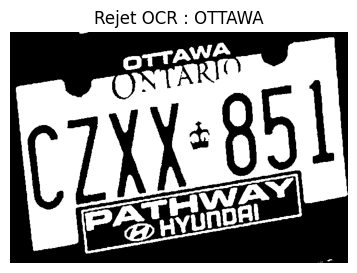

In [16]:
import sys
import re
from pathlib import Path
import cv2
import easyocr
import matplotlib.pyplot as plt
from ultralytics import YOLO

# --- 1. CONFIGURATION ---
class ALPRConfig:
    """Parametres globaux du systeme ALPR."""
    MOTS_IGNORER = {"QUEBEC", "ONTARIO", "CANADA", "JEMESOUVIENS", "YOURSTODISCOVER"}
    CONF_MIN_YOLO = 0.5
    MARGE_CROP_PIXELS = 5

# --- 2. SERVICES ---
class OCRService:
    """Service independant expert en traitement d'image et OCR."""
    def __init__(self, langs=['en']):
        print("[INFO] Initialisation du OCRService (EasyOCR)...")
        self.reader = easyocr.Reader(langs)

    def pretraiter_image(self, img_crop):
        """Pipeline d'amelioration de la nettete."""
        gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
        gray = cv2.bilateralFilter(gray, 11, 17, 17)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return thresh

    def nettoyer_texte(self, texte_brut: str) -> str:
        """Nettoyage strict par Expression Reguliere."""
        return re.sub(r'[^A-Z0-9]', '', texte_brut.upper())

    def valider_plaque(self, texte_nettoye: str) -> bool:
        """Application des regles metier de filtrage."""
        if len(texte_nettoye) < 4:
            return False
        if texte_nettoye in ALPRConfig.MOTS_IGNORER:
            return False
        if not any(char.isdigit() for char in texte_nettoye):
            return False
        return True

    def extraire_candidats(self, image_crop) -> list:
        """Traite le crop, lit l'OCR, filtre et trie les resultats."""
        image_prete = self.pretraiter_image(image_crop)
        resultats_ocr = self.reader.readtext(image_prete)
        
        candidats_valides = []
        
        # Objet de secours pour le diagnostic en cas d'echec
        meilleur_rejet = {
            "texte": "ILLISIBLE", 
            "confiance": 0.0, 
            "image_binaire": image_prete,
            "valide": False
        }

        for (bbox, text, prob) in resultats_ocr:
            t_clean = self.nettoyer_texte(text)
            
            if self.valider_plaque(t_clean):
                candidats_valides.append({
                    "texte": t_clean, 
                    "confiance": prob, 
                    "image_binaire": image_prete,
                    "valide": True
                })
            else:
                # Capture du meilleur texte meme s'il est rejete (pour affichage debug)
                if prob > meilleur_rejet["confiance"]:
                    meilleur_rejet = {
                        "texte": t_clean if t_clean else "VIDE",
                        "confiance": prob,
                        "image_binaire": image_prete,
                        "valide": False
                    }
        
        if candidats_valides:
            # Tri par indice de confiance decroissant si on a des succes
            candidats_valides.sort(key=lambda x: x["confiance"], reverse=True)
            return candidats_valides
        else:
            # Si aucun succes, on retourne l'echec pour permettre l'affichage
            return [meilleur_rejet]

# --- 3. ORCHESTRATEUR ---
class ALPRPipeline:
    """Orchestrateur combinant Vision et OCR."""
    def __init__(self, model_filename: str = "best.pt"):
        try:
            self.base_dir = Path(__file__).resolve().parent
        except NameError:
            self.base_dir = Path.cwd()

        model_path = self.base_dir / model_filename
        print("[INFO] Initialisation du Pipeline ALPR...")
        self.model_path = str(model_path) if model_path.exists() else "yolov8n.pt"
        self.model = YOLO(self.model_path)
        self.ocr_service = OCRService()

    def analyser_image(self, chemin_image: Path):
        """Inference pure sans affichage graphique."""
        if not chemin_image.exists():
            print(f"[ERREUR] Image introuvable : {chemin_image}")
            return []

        img = cv2.imread(str(chemin_image))
        if img is None:
            print(f"[ERREUR] Decode impossible : {chemin_image}")
            return []

        results = self.model.predict(source=img, conf=ALPRConfig.CONF_MIN_YOLO, verbose=False)
        resultats_finaux = []

        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                
                marge = ALPRConfig.MARGE_CROP_PIXELS
                y1_crop = max(0, y1 - marge)
                y2_crop = min(img.shape[0], y2 + marge)
                x1_crop = max(0, x1 - marge)
                x2_crop = min(img.shape[1], x2 + marge)

                plaque_crop = img[y1_crop:y2_crop, x1_crop:x2_crop]
                if plaque_crop.size == 0:
                    continue

                candidats = self.ocr_service.extraire_candidats(plaque_crop)
                if candidats:
                    resultats_finaux.append(candidats[0])

        return resultats_finaux

    def tester_et_afficher(self, chemin_image: Path):
        """Affiche les resultats sur le notebook, y compris les echecs."""
        print(f"\n[INFO] Analyse de l'image en cours : {chemin_image.name}")
        resultats = self.analyser_image(chemin_image)

        if not resultats:
            print("[INFO] YOLO n'a detecte aucun vehicule ou plaque sur l'image.")
            return

        for res in resultats:
            if res["valide"]:
                print(f"[SUCCES] PLAQUE DETECTEE : {res['texte']} (Confiance: {res['confiance']:.2f})")
                titre = f"Lecture : {res['texte']}"
            else:
                print(f"[REJET] Lecture echouee ou filtree : '{res['texte']}' (Confiance: {res['confiance']:.2f})")
                titre = f"Rejet OCR : {res['texte']}"

            plt.figure(figsize=(6, 3))
            plt.imshow(res['image_binaire'], cmap='gray')
            plt.title(titre)
            plt.axis('off')
            plt.show()

# --- BLOC D'EXECUTION PRINCIPAL ---
if __name__ == "__main__":
    try:
        racine_projet = Path(__file__).resolve().parent
    except NameError:
        racine_projet = Path.cwd()
        
    # Ciblage dynamique ciblant le dossier images/new/
    chemin_test = racine_projet / "images" / "new" / "IMG_4214.jpg"
    
    pipeline = ALPRPipeline(model_filename="best.pt")
    pipeline.tester_et_afficher(chemin_test)

In [18]:
import sys
from pathlib import Path
import cv2
import easyocr

class OCRDiagnosticService:
    """
    Service de diagnostic pour evaluer le bruit visuel (textes parasites).
    Instancie le modele EasyOCR une seule fois pour preserver la memoire (Singleton local).
    """
    def __init__(self, langs=['en'], use_gpu=True):
        print("[INFO] Initialisation du Service de Diagnostic OCR...")
        # L'argument gpu=True accelere drastiquement le traitement si CUDA est disponible
        self.reader = easyocr.Reader(langs, gpu=use_gpu)

    def evaluer_bruit_visuel(self, chemin_image: Path):
        """
        Analyse l'image complete (sans predecoupage YOLO) pour lister tous les textes lisibles.
        """
        if not chemin_image.exists():
            print(f"[ERREUR] L'image est introuvable au chemin : {chemin_image}")
            print("[INFO] Verifiez si l'extension est correcte (ex: .jpg au lieu de .HEIC)")
            return

        print(f"[INFO] Chargement de l'image de test : {chemin_image.name}")
        img = cv2.imread(str(chemin_image))
        
        if img is None:
            print("[ERREUR] Impossible de decoder l'image (fichier potentiellement corrompu).")
            return

        print("[INFO] Analyse de l'image entiere en cours (Extraction du bruit visuel)...")
        resultats = self.reader.readtext(img)

        print("\n--- TOUS LES TEXTES DETECTES (SANS FILTRE YOLO) ---")
        if not resultats:
            print("Aucun texte detecte sur cette image.")
        else:
            for (bbox, texte, conf) in resultats:
                print(f" -> '{texte}' (Confiance: {conf:.2f})")
        print("----------------------------------------------------")


# --- BLOC D'EXECUTION PRINCIPAL ---
if __name__ == "__main__":
    # 1. Resolution dynamique du chemin racine
    try:
        base_dir = Path(__file__).resolve().parent
    except NameError:
        base_dir = Path.cwd()

    # 2. Pointage vers le fichier cible (Projet_Capstone_IA/new/IMG_4198.jpg)
    chemin_test = base_dir / "new" / "IMG_4198.jpg"
    
    # 3. Execution securisee
    diagnostic = OCRDiagnosticService()
    diagnostic.evaluer_bruit_visuel(chemin_test)

[INFO] Initialisation du Service de Diagnostic OCR...
[INFO] Chargement de l'image de test : IMG_4198.jpg
[INFO] Analyse de l'image entiere en cours (Extraction du bruit visuel)...

--- TOUS LES TEXTES DETECTES (SANS FILTRE YOLO) ---
 -> 'ONTARIO' (Confiance: 0.73)
 -> 'DHHK* 062' (Confiance: 0.17)
 -> 'YOURS T0 DISCOVER' (Confiance: 0.79)
 -> 'QUTLANDER' (Confiance: 0.70)
 -> 'Ewa' (Confiance: 0.12)
 -> 'MITSUBISHI' (Confiance: 0.97)
----------------------------------------------------


In [19]:
import sys
from pathlib import Path
import mlflow

class MLOpsService:
    """
    Service centralise pour la tracabilite des inferences et des metriques du systeme.
    Utilise SQLite pour eviter les problemes de corruption de fichiers sous Windows/Docker.
    """
    def __init__(self, experiment_name: str = "Parking_Control_System"):
        print("[INFO] Initialisation du MLOpsService...")
        
        # 1. Gestion des chemins avec pathlib
        try:
            self.base_dir = Path(__file__).resolve().parent
        except NameError:
            self.base_dir = Path.cwd()

        # 2. Configuration securisee vers SQLite (Correction du bug Windows)
        self.db_path = self.base_dir / "mlflow.db"
        # as_posix() assure que le chemin a des slashs compatibles avec l'URI (file:///)
        self.tracking_uri = f"sqlite:///{self.db_path.as_posix()}"

        # 3. Parametrage du serveur interne MLflow
        mlflow.set_tracking_uri(self.tracking_uri)
        mlflow.set_experiment(experiment_name)
        print(f"[INFO] Suivi MLflow connecte a la base : {self.tracking_uri}")

    def journaliser_inference(self, plaque: str, confiance: float, statut: str):
        """
        Enregistre les donnees d'une requete d'analyse dans la base de donnees.
        """
        try:
            # Ouverture securisee : garantit la fermeture meme en cas d'erreur
            with mlflow.start_run(run_name="Inference_API_Tablette"):
                
                # Parametres de configuration du systeme
                mlflow.log_param("modele_vision", "YOLOv8")
                mlflow.log_param("moteur_ocr", "EasyOCR_Optimise")
                
                # Parametres metiers (ce qu'on a vu)
                mlflow.log_param("plaque_detectee", plaque)
                mlflow.log_param("statut_vehicule", statut)
                
                # Metriques (ce qu'on peut graphiquer ou moyenner)
                mlflow.log_metric("confiance_lecture", confiance)
                
            print(f"[INFO] MLOps : Tracabilite sauvegardee pour le vehicule [{plaque}].")
            
        except Exception as e:
            print(f"[ERREUR] Le suivi MLflow a echoue (Operation ignoree pour ne pas bloquer l'API) : {e}")

# --- BLOC D'EXECUTION PRINCIPAL ---
if __name__ == "__main__":
    # Instanciation du service
    tracker = MLOpsService()
    
    # Simulation d'un enregistrement lors du passage d'un vehicule
    tracker.journaliser_inference(plaque="DFHP360", confiance=0.92, statut="AUTORISE")

2026/04/21 20:17:46 INFO mlflow.tracking.fluent: Experiment with name 'Parking_Control_System' does not exist. Creating a new experiment.


[INFO] Initialisation du MLOpsService...
[INFO] Suivi MLflow connecte a la base : sqlite:///c:/Users/user/Desktop/001 INTELLIGENCE ARTIFICIELLE EN INFORMATIQUE/Session 4 Semestre 4 IA 2/Projet Capstone en IA/Projet_Capstone_IA/mlflow.db
[INFO] MLOps : Tracabilite sauvegardee pour le vehicule [DFHP360].


In [20]:
import sys
import re
from pathlib import Path
import cv2
import easyocr
import mlflow
from ultralytics import YOLO

# --- 1. CONFIGURATION DES PARAMETRES ---
class ALPRConfig:
    """Regroupe les constantes et seuils du systeme."""
    MOTS_IGNORER = {"QUEBEC", "ONTARIO", "CANADA"}
    CONF_MIN_YOLO = 0.5
    LONGUEUR_MIN_PLAQUE = 4
    EXP_NAME = "Parking_Control_System"

# --- 2. SERVICES DE PRODUCTION ---
class MLOpsService:
    """Gere la tracabilite et la journalisation des performances."""
    def __init__(self):
        try:
            self.base_dir = Path(__file__).resolve().parent
        except NameError:
            self.base_dir = Path.cwd()
            
        # Utilisation de SQLite pour eviter les erreurs de fichiers Windows (desktop.ini)
        self.db_path = self.base_dir / "mlflow.db"
        self.tracking_uri = f"sqlite:///{self.db_path.as_posix()}"
        
        mlflow.set_tracking_uri(self.tracking_uri)
        mlflow.set_experiment(ALPRConfig.EXP_NAME)

    def log_resultat(self, nom_image, plaque, confiance):
        """Enregistre une run MLflow pour une analyse specifique."""
        with mlflow.start_run(run_name=f"Analyse_{nom_image}"):
            mlflow.log_param("image_source", nom_image)
            mlflow.log_param("model_type", "YOLOv8n")
            
            if plaque:
                mlflow.log_metric("ocr_confidence", float(confiance))
                mlflow.set_tag("detected_plate", plaque)
                mlflow.set_tag("status", "SUCCESS")
            else:
                mlflow.set_tag("status", "FAILED")

class OCRService:
    """Expert en extraction de texte."""
    def __init__(self, langs=['en']):
        print("[INFO] Initialisation du OCRService...")
        self.reader = easyocr.Reader(langs)

    def extraire_plaque(self, image_crop):
        """Lit et valide le texte selon les regles metier."""
        results = self.reader.readtext(image_crop)
        for (_, text, prob) in results:
            t_clean = re.sub(r'[^A-Z0-9]', '', text.upper())
            if len(t_clean) >= ALPRConfig.LONGUEUR_MIN_PLAQUE and any(c.isdigit() for c in t_clean):
                if t_clean not in ALPRConfig.MOTS_IGNORER:
                    return t_clean, prob
        return None, 0.0

# --- 3. ORCHESTRATEUR (PIPELINE) ---
class ALPRPipeline:
    """Orchestre la vision, l'OCR et le monitoring."""
    def __init__(self, model_filename="best.pt"):
        try:
            self.base_dir = Path(__file__).resolve().parent
        except NameError:
            self.base_dir = Path.cwd()
            
        self.images_dir = self.base_dir / "images"
        model_path = self.base_dir / model_filename
        
        # Chargement unique des modeles (Singleton pattern)
        self.model = YOLO(str(model_path) if model_path.exists() else "yolov8n.pt")
        self.ocr_service = OCRService()
        self.mlops_service = MLOpsService()
        print("[INFO] Pipeline pret pour l'integration MLflow.")

    def executer_test_complet(self, nom_image):
        """Pipeline complet avec monitoring."""
        chemin_image = self.images_dir / nom_image
        img = cv2.imread(str(chemin_image))
        
        if img is None:
            print(f"[ERREUR] Image {nom_image} introuvable.")
            return

        # Inference
        results = self.model.predict(source=img, conf=ALPRConfig.CONF_MIN_YOLO, verbose=False)
        
        plaque_finale = None
        confiance_finale = 0.0

        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                # Securite des bordures
                y1, y2 = max(0, y1), min(img.shape[0], y2)
                x1, x2 = max(0, x1), min(img.shape[1], x2)
                
                crop = img[y1:y2, x1:x2]
                plaque_finale, confiance_finale = self.ocr_service.extraire_plaque(crop)

        # Journalisation automatique dans la base de donnees MLOps
        self.mlops_service.log_resultat(nom_image, plaque_finale, confiance_finale)
        
        if plaque_finale:
            print(f"[SUCCES] Plaque : {plaque_finale} enregistree dans MLflow.")
        else:
            print("[INFO] Aucune plaque valide detectee. Tag 'FAILED' envoye a MLflow.")

# --- EXECUTION ---
if __name__ == "__main__":
    pipeline = ALPRPipeline()
    pipeline.executer_test_complet("9.jpg")

[INFO] Initialisation du OCRService...
[INFO] Pipeline pret pour l'integration MLflow.
[SUCCES] Plaque : AXO5RL enregistree dans MLflow.


In [21]:
import sys
import re
from pathlib import Path
import cv2
import easyocr
import mlflow
from ultralytics import YOLO

# --- 1. CONFIGURATION ---
class ALPRConfig:
    MOTS_IGNORER = {"QUEBEC", "ONTARIO", "CANADA"}
    CONF_MIN_YOLO = 0.6
    LONGUEUR_MIN_PLAQUE = 4
    MARGE_CROP_PIXELS = 5
    FRAME_SKIP = 5
    EXP_NAME = "Parking_Control_Video_Tests"

# --- 2. SERVICES INDEPENDANTS ---
class MLOpsService:
    """Gere la tracabilite via une base SQLite robuste."""
    def __init__(self):
        try:
            self.base_dir = Path(__file__).resolve().parent
        except NameError:
            self.base_dir = Path.cwd()
            
        self.db_path = self.base_dir / "mlflow.db"
        self.tracking_uri = f"sqlite:///{self.db_path.as_posix()}"
        
        mlflow.set_tracking_uri(self.tracking_uri)
        mlflow.set_experiment(ALPRConfig.EXP_NAME)
        print(f"[INFO] MLOps connecte a {self.tracking_uri}")

class OCRService:
    """Expert OCR avec pretraitement integre."""
    def __init__(self, langs=['en']):
        print("[INFO] Initialisation du OCRService...")
        self.reader = easyocr.Reader(langs)

    def pretraiter_image(self, img_crop):
        gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
        gray = cv2.bilateralFilter(gray, 11, 17, 17)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return thresh

    def extraire_plaque(self, image_crop):
        image_prete = self.pretraiter_image(image_crop)
        resultats = self.reader.readtext(image_prete)
        
        for (bbox, text, prob) in resultats:
            t_clean = re.sub(r'[^A-Z0-9]', '', text.upper())
            if len(t_clean) >= ALPRConfig.LONGUEUR_MIN_PLAQUE and any(c.isdigit() for c in t_clean):
                if t_clean not in ALPRConfig.MOTS_IGNORER:
                    return t_clean, prob
        return None, 0.0

# --- 3. ORCHESTRATEUR VIDEO ---
class ALPRVideoPipeline:
    """Orchestrateur traitant les flux continus (Video/Camera)."""
    def __init__(self, model_filename="best.pt"):
        try:
            self.base_dir = Path(__file__).resolve().parent
        except NameError:
            self.base_dir = Path.cwd()
            
        self.videos_dir = self.base_dir / "videos"
        model_path = self.base_dir / model_filename
        
        self.model = YOLO(str(model_path) if model_path.exists() else "yolov8n.pt")
        self.ocr_service = OCRService()
        self.mlops_service = MLOpsService()

    def traiter_flux_video(self, nom_video: str, mode_headless: bool = False):
        chemin_video = self.videos_dir / nom_video
        
        if not chemin_video.exists():
            print(f"[ERREUR] La video {nom_video} est introuvable au chemin : {chemin_video}")
            return

        cap = cv2.VideoCapture(str(chemin_video))
        if not cap.isOpened():
            print("[ERREUR] Impossible d'ouvrir le flux video.")
            return

        derniere_plaque_lue = ""
        compteur_frames = 0
        
        print(f"[INFO] Debut de l'analyse video : {nom_video} (Headless: {mode_headless})")

        with mlflow.start_run(run_name=f"Analyse_Video_{nom_video}"):
            mlflow.log_param("fichier_video", nom_video)
            mlflow.log_param("frame_skip", ALPRConfig.FRAME_SKIP)
            
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                
                compteur_frames += 1
                
                if compteur_frames % ALPRConfig.FRAME_SKIP != 0:
                    continue

                hauteur_img, largeur_img = frame.shape[:2]
                results = self.model.predict(source=frame, conf=ALPRConfig.CONF_MIN_YOLO, verbose=False)
                
                for r in results:
                    for box in r.boxes:
                        x1, y1, x2, y2 = map(int, box.xyxy[0])
                        
                        # Marge avec prevention de debordement
                        marge = ALPRConfig.MARGE_CROP_PIXELS
                        y1_crop = max(0, y1 - marge)
                        y2_crop = min(hauteur_img, y2 + marge)
                        x1_crop = max(0, x1 - marge)
                        x2_crop = min(largeur_img, x2 + marge)
                        
                        plaque_crop = frame[y1_crop:y2_crop, x1_crop:x2_crop]
                        
                        if plaque_crop.size == 0:
                            continue
                        
                        plaque_texte, confiance = self.ocr_service.extraire_plaque(plaque_crop)
                        
                        if plaque_texte and plaque_texte != derniere_plaque_lue:
                            print(f"[SUCCES] Vehicule detecte : {plaque_texte} (Confiance: {confiance:.2f})")
                            derniere_plaque_lue = plaque_texte
                            
                            mlflow.log_text(plaque_texte, f"plates/frame_{compteur_frames}.txt")
                            mlflow.log_metric("confiance_detection", float(confiance), step=compteur_frames)
                            
                            # Feedback visuel (seulement si mode fenetre actif)
                            if not mode_headless:
                                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                                cv2.putText(frame, plaque_texte, (x1, max(0, y1 - 10)), 
                                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

                if not mode_headless:
                    cv2.imshow("Controle Parking La Cite - IA Video", frame)
                    if cv2.waitKey(1) & 0xFF == ord('q'):
                        print("[INFO] Interruption manuelle.")
                        break
                else:
                    if compteur_frames % 50 == 0:
                        snapshot_path = self.base_dir / f"snapshot_frame_{compteur_frames}.jpg"
                        cv2.imwrite(str(snapshot_path), frame)

        cap.release()
        if not mode_headless:
            cv2.destroyAllWindows()
        
        print("[INFO] Analyse video terminee et session MLflow fermee proprement.")

# --- BLOC D'EXECUTION PRINCIPAL ---
if __name__ == "__main__":
    pipeline_video = ALPRVideoPipeline(model_filename="best.pt")
    # Remplacez IMG_4217.MOV par le nom correct de votre video dans le dossier 'videos'
    pipeline_video.traiter_flux_video("IMG_4217.MOV", mode_headless=False)

[INFO] Initialisation du OCRService...


2026/04/21 20:29:07 INFO mlflow.tracking.fluent: Experiment with name 'Parking_Control_Video_Tests' does not exist. Creating a new experiment.


[INFO] MLOps connecte a sqlite:///c:/Users/user/Desktop/001 INTELLIGENCE ARTIFICIELLE EN INFORMATIQUE/Session 4 Semestre 4 IA 2/Projet Capstone en IA/Projet_Capstone_IA/mlflow.db
[INFO] Debut de l'analyse video : IMG_4217.MOV (Headless: False)
[SUCCES] Vehicule detecte : Z20VRE (Confiance: 0.52)
[SUCCES] Vehicule detecte : Z2CVPE (Confiance: 0.43)
[SUCCES] Vehicule detecte : 1676YZD (Confiance: 0.21)
[SUCCES] Vehicule detecte : 1676 (Confiance: 0.24)
[SUCCES] Vehicule detecte : 1G76YZD (Confiance: 0.21)
[SUCCES] Vehicule detecte : 1676 (Confiance: 0.82)
[SUCCES] Vehicule detecte : 1G76YZD (Confiance: 0.29)
[SUCCES] Vehicule detecte : JERK186 (Confiance: 0.34)
[SUCCES] Vehicule detecte : DEAH186 (Confiance: 0.11)
[SUCCES] Vehicule detecte : DEWH186 (Confiance: 0.23)
[SUCCES] Vehicule detecte : DEW1B6 (Confiance: 0.03)
[SUCCES] Vehicule detecte : JERK186 (Confiance: 0.26)
[SUCCES] Vehicule detecte : LEXH186 (Confiance: 0.29)
[SUCCES] Vehicule detecte : DEXH186 (Confiance: 0.33)
[SUCCES] 

In [ ]:
# import os
# import cv2
# import re
# import easyocr
# import mlflow 
# from ultralytics import YOLO
# from collections import Counter

# # --- DÉFINITION DYNAMIQUE DU CHEMIN (STANDARD LOGICIEL) ---
# BASE_DIR = os.path.dirname(os.path.abspath(__file__))

# BASE_ABONNES = [
#     "DFHP360",
#     "CYLR602",
#     "DJAV098"
# ]

# LISTE_NOIRE_PROVINCES = [
#     "QUEBEC",
#     "ONTARIO",
#     "CANADA",
#     "YOURSTODISCOVER",
#     "JEMESOUVIENS"
# ]

# # --- 1. CONFIGURATION MLOPS SÉCURISÉE ---
# chemin_mlruns = os.path.join(BASE_DIR, "mlruns")
# mlflow.set_tracking_uri(f"file:///{chemin_mlruns.replace(os.sep, '/')}")
# mlflow.set_experiment("Parking_Control_System")

# # --- 2. CONFIGURATION & CHARGEMENT DES MODÈLES ---
# chemin_modele = os.path.join(BASE_DIR, "best.pt")
# if not os.path.exists(chemin_modele):
#     print(f"Alerte : {chemin_modele} introuvable. Utilisation de yolov8n.pt")
#     chemin_modele = "yolov8n.pt"

# print("Chargement des modèles (YOLO + EasyOCR)...")
# model = YOLO(chemin_modele)
# reader = easyocr.Reader(['en'])

# SEUIL_CONFIANCE_OCR = 0.20  # Ignorer les lectures trop faibles

# # --- 3. FONCTION DE PRÉTRAITEMENT ---
# def ameliorer_plaque(img_crop):
#     """Améliore le contraste pour aider l'OCR"""
#     gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
#     gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
#     thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
#     return thresh

# # --- 4. TRAITEMENT DU FLUX VIDÉO ENCAPSULÉ ---
# def analyser_video_complete(nom_video, mode_headless=False):
#     """
#     Fonction principale de production pour l'analyse vidéo.
#     """
#     chemin_video = os.path.join(BASE_DIR, "videos", nom_video)
    
#     if not os.path.exists(chemin_video):
#         print(f"Erreur critique : Vidéo introuvable au chemin {chemin_video}")
#         return

#     cap = cv2.VideoCapture(chemin_video)
#     if not cap.isOpened():
#         print("Erreur : Impossible d'ouvrir le flux vidéo.")
#         return

#     # Initialisation des variables de mémoire locale
#     memoire_plaques = []
#     derniere_plaque_affichee = ""

#     with mlflow.start_run(run_name=f"Video_Final_{nom_video.split('.')[0]}"):
#         while cap.isOpened():
#             ret, frame = cap.read()
#             if not ret: 
#                 break

#             results = model.predict(source=frame, conf=0.6, verbose=False)
            
#             # Variables pour dessiner la boîte au bon endroit
#             x1_draw, y1_draw, x2_draw, y2_draw = 0, 0, 0, 0
#             box_trouvee = False

#             for r in results:
#                 for box in r.boxes:
#                     box_trouvee = True
#                     # Sécurisation des limites de l'image (Out of bounds)
#                     x1, y1, x2, y2 = map(int, box.xyxy[0])
#                     x1_draw, y1_draw, x2_draw, y2_draw = x1, y1, x2, y2 # Sauvegarde pour le dessin
                    
#                     y1_safe, y2_safe = max(0, y1), min(frame.shape[0], y2)
#                     x1_safe, x2_safe = max(0, x1), min(frame.shape[1], x2)
                    
#                     plaque_crop = frame[y1_safe:y2_safe, x1_safe:x2_safe]
                    
#                     if plaque_crop.size == 0:
#                         continue
                    
#                     # OCR et traitement
#                     plaque_prete = ameliorer_plaque(plaque_crop)
#                     result_ocr = reader.readtext(plaque_prete)
                    
#                     for (_, text, prob) in result_ocr:
#                         t_clean = re.sub(r'[^A-Z0-9]', '', text.upper())
#                         if len(t_clean) >= 4 and any(c.isdigit() for c in t_clean):
#                             if t_clean not in LISTE_NOIRE_PROVINCES:
#                                 if prob > SEUIL_CONFIANCE_OCR:
#                                     memoire_plaques.append(t_clean)

#             # DESSINER L'ENCADREMENT SUR CHAQUE FRAME 
#             if memoire_plaques and box_trouvee:
#                 occurences = Counter(memoire_plaques)
#                 plaque_stable, nb = occurences.most_common(1)[0]
#                 couleur_box = (0, 255, 0) if plaque_stable in BASE_ABONNES else (0, 0, 255)
                
#                 # Dessine le rectangle autour de la plaque
#                 cv2.rectangle(frame, (x1_draw, y1_draw), (x2_draw, y2_draw), couleur_box, 3)
#                 cv2.putText(frame, plaque_stable, (x1_draw, max(0, y1_draw - 10)), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.8, couleur_box, 2)

#             # LOGIQUE DE STABILISATION (VOTE) ET BANDEAU INFO 
#             if len(memoire_plaques) > 20:
#                 memoire_plaques.pop(0)

#             if memoire_plaques:
#                 occurences = Counter(memoire_plaques)
#                 plaque_stable, nb = occurences.most_common(1)[0]

#                 if nb > 1:
#                     status = "AUTORISE" if plaque_stable in BASE_ABONNES else "NON AUTORISE"
#                     couleur_statut = (0, 255, 0) if status == "AUTORISE" else (0, 0, 255)
                    
#                     # Bandeau récapitulatif en haut
#                     cv2.rectangle(frame, (10, 10), (450, 80), (0, 0, 0), -1)
#                     cv2.putText(frame, f"PLAQUE: {plaque_stable}", (20, 40), 
#                                 cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
#                     cv2.putText(frame, f"STATUT: {status}", (20, 70), 
#                                 cv2.FONT_HERSHEY_SIMPLEX, 0.8, couleur_statut, 2)
                    
#                     if plaque_stable != derniere_plaque_affichee:
#                         print(f"[{status}] Véhicule détecté : {plaque_stable} (Stabilité: {nb}/20)")
#                         mlflow.log_metric("confiance_vote", nb/20)
#                         derniere_plaque_affichee = plaque_stable

#             # AFFICHAGE DE L'INTERFACE VISUELLE
#             if not mode_headless:
#                 ratio = 0.8 
#                 largeur = int(frame.shape[1] * ratio)
#                 hauteur = int(frame.shape[0] * ratio)
#                 frame_redimensionne = cv2.resize(frame, (largeur, hauteur))

#                 cv2.imshow("Controle Parking La Cite - IA", frame_redimensionne)
#                 if cv2.waitKey(1) & 0xFF == ord('q'): 
#                     break

#     cap.release()
#     if not mode_headless:
#         cv2.destroyAllWindows()
#     print("Fin de l'analyse vidéo.")

# # --- BLOC D'EXÉCUTION PRINCIPAL ---
# if __name__ == "__main__":
#     # Remplacer par n'importe quelle vidéo du dossier "videos"
#     analyser_video_complete("IMG_4318.MOV", mode_headless=False)

[NON AUTORISE] Véhicule détecté : FHP360
[NON AUTORISE] Véhicule détecté : IFHP360
[AUTORISE] Véhicule détecté : DFHP360
[NON AUTORISE] Véhicule détecté : IFHP360
[AUTORISE] Véhicule détecté : CYLR602
[NON AUTORISE] Véhicule détecté : 197ZRS
[AUTORISE] Véhicule détecté : DJAV098
[NON AUTORISE] Véhicule détecté : IJCR186
[NON AUTORISE] Véhicule détecté : IDJCR186
[NON AUTORISE] Véhicule détecté : IJCR186
[NON AUTORISE] Véhicule détecté : DJCR186
[NON AUTORISE] Véhicule détecté : JCR186
[NON AUTORISE] Véhicule détecté : IDJCR1861
[NON AUTORISE] Véhicule détecté : IJCR186
[NON AUTORISE] Véhicule détecté : JCR186
[NON AUTORISE] Véhicule détecté : 091PSB
[NON AUTORISE] Véhicule détecté : W91PSB
[NON AUTORISE] Véhicule détecté : IW91PSB
[NON AUTORISE] Véhicule détecté : 491PSB
[NON AUTORISE] Véhicule détecté : 091PSB
[NON AUTORISE] Véhicule détecté : W91PSB
[NON AUTORISE] Véhicule détecté : DHHX339
[NON AUTORISE] Véhicule détecté : HHX339
[NON AUTORISE] Véhicule détecté : DCSM719
[NON AUTORI

In [22]:
import sys
import re
from pathlib import Path
import cv2
import easyocr
import mlflow
from ultralytics import YOLO
from collections import Counter

# --- 1. CONFIGURATION CENTRALISEE ---
class ALPRConfig:
    """Parametres metier et techniques globaux."""
    BASE_ABONNES = {"DFHP360", "CYLR602", "DJAV098"}
    MOTS_IGNORER = {"QUEBEC", "ONTARIO", "CANADA", "YOURSTODISCOVER", "JEMESOUVIENS"}
    CONF_MIN_YOLO = 0.6
    CONF_MIN_OCR = 0.20
    LONGUEUR_MIN_PLAQUE = 4
    MARGE_CROP_PIXELS = 5
    TAILLE_MEMOIRE_VOTE = 20
    EXP_NAME = "Parking_Control_System"

# --- 2. MICROSERVICES ---
class MLOpsService:
    """Gere la tracabilite via SQLite pour garantir l'integrite sous Windows/Docker."""
    def __init__(self):
        try:
            self.base_dir = Path(__file__).resolve().parent
        except NameError:
            self.base_dir = Path.cwd()
            
        self.db_path = self.base_dir / "mlflow.db"
        self.tracking_uri = f"sqlite:///{self.db_path.as_posix()}"
        
        mlflow.set_tracking_uri(self.tracking_uri)
        mlflow.set_experiment(ALPRConfig.EXP_NAME)

class OCRService:
    """Gere le traitement d'image et l'extraction de texte."""
    def __init__(self, langs=['en']):
        print("[INFO] Initialisation du OCRService...")
        self.reader = easyocr.Reader(langs)

    def pretraiter_image(self, img_crop):
        gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return thresh

    def nettoyer_texte(self, texte_brut: str) -> str:
        return re.sub(r'[^A-Z0-9]', '', texte_brut.upper())

    def lire_plaque(self, image_crop):
        """Retourne les lectures valides d'une decoupe."""
        image_prete = self.pretraiter_image(image_crop)
        resultats = self.reader.readtext(image_prete)
        
        lectures_valides = []
        for (_, text, prob) in resultats:
            t_clean = self.nettoyer_texte(text)
            if len(t_clean) >= ALPRConfig.LONGUEUR_MIN_PLAQUE and any(c.isdigit() for c in t_clean):
                if t_clean not in ALPRConfig.MOTS_IGNORER and prob > ALPRConfig.CONF_MIN_OCR:
                    lectures_valides.append(t_clean)
        return lectures_valides

class PlateTracker:
    """
    Gestionnaire de memoire a court terme pour stabiliser les lectures (Systeme de vote).
    """
    def __init__(self, max_size=ALPRConfig.TAILLE_MEMOIRE_VOTE):
        self.memoire = []
        self.max_size = max_size
        self.historique_global = set()

    def ajouter_lectures(self, lectures: list):
        for lecture in lectures:
            self.memoire.append(lecture)
            self.historique_global.add(lecture)
            
        # Maintien de la taille de la fenetre glissante
        while len(self.memoire) > self.max_size:
            self.memoire.pop(0)

    def obtenir_plaque_stable(self):
        """Retourne la plaque la plus frequente et son nombre d'occurences."""
        if not self.memoire:
            return None, 0
        occurences = Counter(self.memoire)
        return occurences.most_common(1)[0]

    def total_plaques_uniques(self):
        return len(self.historique_global)

# --- 3. ORCHESTRATEUR VIDEO ---
class ALPRVideoPipeline:
    """Assemble la Vision, l'OCR, le Tracker et la Tracabilite."""
    def __init__(self, model_filename="best.pt"):
        try:
            self.base_dir = Path(__file__).resolve().parent
        except NameError:
            self.base_dir = Path.cwd()
            
        self.videos_dir = self.base_dir / "videos"
        model_path = self.base_dir / model_filename
        
        self.model = YOLO(str(model_path) if model_path.exists() else "yolov8n.pt")
        self.ocr_service = OCRService()
        self.mlops = MLOpsService()

    def analyser_video_complete(self, nom_video: str, mode_headless: bool = False):
        chemin_video = self.videos_dir / nom_video
        
        if not chemin_video.exists():
            print(f"[ERREUR] Video introuvable : {chemin_video}")
            return

        cap = cv2.VideoCapture(str(chemin_video))
        tracker = PlateTracker()
        derniere_plaque_journalisee = ""

        with mlflow.start_run(run_name=f"Analyse_{nom_video.split('.')[0]}"):
            # Enregistrement de la configuration initiale
            mlflow.log_param("seuil_ocr", ALPRConfig.CONF_MIN_OCR)
            mlflow.log_param("taille_fenetre_vote", ALPRConfig.TAILLE_MEMOIRE_VOTE)
            mlflow.log_param("fichier_video", nom_video)

            print(f"[INFO] Demarrage de l'analyse video : {nom_video}")

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break

                hauteur_img, largeur_img = frame.shape[:2]
                results = self.model.predict(source=frame, conf=ALPRConfig.CONF_MIN_YOLO, verbose=False)
                
                box_trouvee = False
                x1_draw, y1_draw, x2_draw, y2_draw = 0, 0, 0, 0

                # 1. Phase de Detection et Extraction
                for r in results:
                    for box in r.boxes:
                        box_trouvee = True
                        x1, y1, x2, y2 = map(int, box.xyxy[0])
                        x1_draw, y1_draw, x2_draw, y2_draw = x1, y1, x2, y2
                        
                        marge = ALPRConfig.MARGE_CROP_PIXELS
                        y1_crop = max(0, y1 - marge)
                        y2_crop = min(hauteur_img, y2 + marge)
                        x1_crop = max(0, x1 - marge)
                        x2_crop = min(largeur_img, x2 + marge)
                        
                        plaque_crop = frame[y1_crop:y2_crop, x1_crop:x2_crop]
                        if plaque_crop.size == 0: continue
                        
                        lectures = self.ocr_service.lire_plaque(plaque_crop)
                        tracker.ajouter_lectures(lectures)

                # 2. Phase de Stabilisation (Vote) et Affichage
                plaque_stable, nb_votes = tracker.obtenir_plaque_stable()

                if plaque_stable and box_trouvee:
                    est_abonne = plaque_stable in ALPRConfig.BASE_ABONNES
                    couleur = (0, 255, 0) if est_abonne else (0, 0, 255)
                    statut = "AUTORISE" if est_abonne else "NON AUTORISE"

                    # Dessin du rectangle de suivi
                    cv2.rectangle(frame, (x1_draw, y1_draw), (x2_draw, y2_draw), couleur, 3)
                    cv2.putText(frame, plaque_stable, (x1_draw, max(0, y1_draw - 10)), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.8, couleur, 2)

                    # Si la plaque est confirmee par plusieurs votes
                    if nb_votes > 1:
                        cv2.rectangle(frame, (10, 10), (450, 80), (0, 0, 0), -1)
                        cv2.putText(frame, f"PLAQUE: {plaque_stable}", (20, 40), 
                                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
                        cv2.putText(frame, f"STATUT: {statut}", (20, 70), 
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, couleur, 2)
                        
                        # Journalisation MLflow au changement d'etat
                        if plaque_stable != derniere_plaque_journalisee:
                            print(f"[EVENEMENT] [{statut}] Vehicule detecte : {plaque_stable} (Stabilite: {nb_votes}/{ALPRConfig.TAILLE_MEMOIRE_VOTE})")
                            mlflow.log_metric("stablite_vote", nb_votes / ALPRConfig.TAILLE_MEMOIRE_VOTE)
                            derniere_plaque_journalisee = plaque_stable

                # 3. Rendu visuel
                if not mode_headless:
                    frame_resize = cv2.resize(frame, (int(largeur_img * 0.8), int(hauteur_img * 0.8)))
                    cv2.imshow("Controle Parking La Cite - IA", frame_resize)
                    if cv2.waitKey(1) & 0xFF == ord('q'): 
                        print("[INFO] Interruption manuelle.")
                        break

            # --- 4. CLOTURE ET RESUME MLOPS ---
            mlflow.log_metric("total_plaques_uniques", tracker.total_plaques_uniques())
            statut_final = 1 if derniere_plaque_journalisee in ALPRConfig.BASE_ABONNES else 0
            mlflow.log_metric("statut_dernier_vehicule", statut_final)

        cap.release()
        if not mode_headless: 
            cv2.destroyAllWindows()
        print("[INFO] Analyse terminee. Tracabilite securisee dans MLflow.")

# --- EXECUTION ---
if __name__ == "__main__":
    pipeline = ALPRVideoPipeline()
    pipeline.analyser_video_complete("IMG_4318.MOV", mode_headless=False)

[INFO] Initialisation du OCRService...
[INFO] Demarrage de l'analyse video : IMG_4318.MOV
[EVENEMENT] [AUTORISE] Vehicule detecte : DFHP360 (Stabilite: 2/20)
[EVENEMENT] [NON AUTORISE] Vehicule detecte : IFHP360 (Stabilite: 2/20)
[EVENEMENT] [AUTORISE] Vehicule detecte : DFHP360 (Stabilite: 3/20)
[EVENEMENT] [NON AUTORISE] Vehicule detecte : FHP360 (Stabilite: 6/20)
[EVENEMENT] [AUTORISE] Vehicule detecte : DFHP360 (Stabilite: 7/20)
[EVENEMENT] [AUTORISE] Vehicule detecte : CYLR602 (Stabilite: 5/20)
[EVENEMENT] [NON AUTORISE] Vehicule detecte : 197ZRS (Stabilite: 6/20)
[EVENEMENT] [NON AUTORISE] Vehicule detecte : 097ZRS (Stabilite: 6/20)
[EVENEMENT] [NON AUTORISE] Vehicule detecte : 197ZRS (Stabilite: 5/20)
[EVENEMENT] [NON AUTORISE] Vehicule detecte : 097ZRS (Stabilite: 5/20)
[EVENEMENT] [AUTORISE] Vehicule detecte : DJAV098 (Stabilite: 6/20)
[EVENEMENT] [NON AUTORISE] Vehicule detecte : JCR186 (Stabilite: 4/20)
[EVENEMENT] [NON AUTORISE] Vehicule detecte : IJCR186 (Stabilite: 3/20)
